# This notebook presents a minimal example of a scattering rate calculation for a direct detection experiment


First we can load in a matplotlib style sheet to make the plots look nice, and also define some constants

In [1]:
from numpy import *
from scipy.special import erf
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Matplotlib style file
plt.style.use('sty.mplstyle')

# Some useful constants
m_p_keV = 0.9315*1e6 # proton mass in keV
c_cm = 2.99792458e8*100.0  # speed of light in cm/s
c_km = 2.99792458e8/1000.0 # speed of light in km/s
GeV_2_kg = 1.0e6*1.783e-33 # GeV to kg conversion
seconds2year = 365.25*3600*24

# First let us look at $g(v_{\rm min})$

The first ingredient we need is a function called the "Mean inverse speed". This is a function, $g(v_{\rm min})$ which is equal to the mean value of the inverse dark matter speed $v^{-1}$, above a cutoff of $v_{\rm min}$. This is a slightly obscure thing but comes about when we derive the scattering rate formula. It turns out that the event rate at a particular energy is proportional to this function.

\begin{equation}
g(v_{\rm min}) = \int_{v_{\rm min}}^\infty \frac{1}{v} f(v) dv
\end{equation}

where we assume a Gaussian distribution for the dark matter velocities

\begin{equation}
f(v) \sim v^2 \exp\bigg(-\frac{(v+v_{\rm lab})^2}{2\sigma^2_v}\bigg)
\end{equation}

The main parameters that go into $f(v)$ (these are assumptions) are:
* $\sigma_v = 167$ km/s - this is the width of the Gaussian distribution of speeds
* $v_{\rm esc} = 533$ km/s - this is the escape speed of the galaxy (i.e. the maximum speed the dark matter can have)
* $v_{\rm lab} = 245.6$ km/s - this is the velocity with which we are moving **through** the dark matter halo (i.e. the speed of the DM wind)

Below is an analytic calculation of that integral.


In [2]:
from scipy.special import erf

#-------------------- Mean Inverse Speed (for Gaussian f(v)) --------------------------#

def MeanInverseSpeed(v_min,sig_v=167.0,v_esc=533.0,v_lab=245.6):
    N_esc = erf(v_esc/(sqrt(2.0)*sig_v))\
            -sqrt(2.0/pi)*(v_esc/sig_v)*exp(-v_esc**2.0/(2.0*sig_v**2.0))
    
    # Define:
    v_0 = sig_v*sqrt(2.0)
    x = v_min/v_0
    z = v_esc/v_0
    y = v_lab/v_0
    
    # Set up conditional terms
    g = zeros_like(v_min)
    g[(x<abs(y-z))&(z<y)] = (1.0/(v_0*y))
    g2 = (1.0/(2.0*N_esc*v_0*y))*(erf(x+y)-erf(x-y)-(4.0/sqrt(pi))*y*exp(-z**2))
    g3 = (1.0/(2.0*N_esc*v_0*y))*(erf(z)-erf(x-y)-(2.0/sqrt(pi))*(y+z-x)*exp(-z**2))
    
    # Apply conditions
    g[(x<abs(y-z))&(z>y)] = g2[(x<abs(y-z))&(z>y)]
    g[(abs(y-z)<x)&(x<(y+z))] = g3[(abs(y-z)<x)&(x<(y+z))]
    g[(y+z)<x] = 0.0
    
    return g

#here we are defining the clumpiness version of g(v_min) and the dark matter halo (disregard)
def g(v_min,v_lab):
    return 0.9 * MeanInverseSpeed(v_min) + 0.1 * MeanInverseSpeed(v_min, v_lab=500.0, sig_v=10.0)

## Now we can plot $g(v_{\rm min})$ for a few parameter choices, to look at the effect of changing one of the parameters, e.g the velocity of the lab

Notice how $g(v_{\rm min})$ has units of inverse speed

In [3]:
#here i am just changing the sample g function from before (disregard)
def g(v_min, v_lab_dependency):
    return 0.9 * MeanInverseSpeed(v_min) + 0.1 * MeanInverseSpeed(v_min, v_lab=v_lab_dependency, sig_v=10.0)

# Example usage:
v_min_values = [1.0, 2.0, 3.0]
v_lab_dependency_value = 500.0
result = g(v_min_values, v_lab_dependency_value)

print(result)

[0.00337408 0.003374   0.00337387]


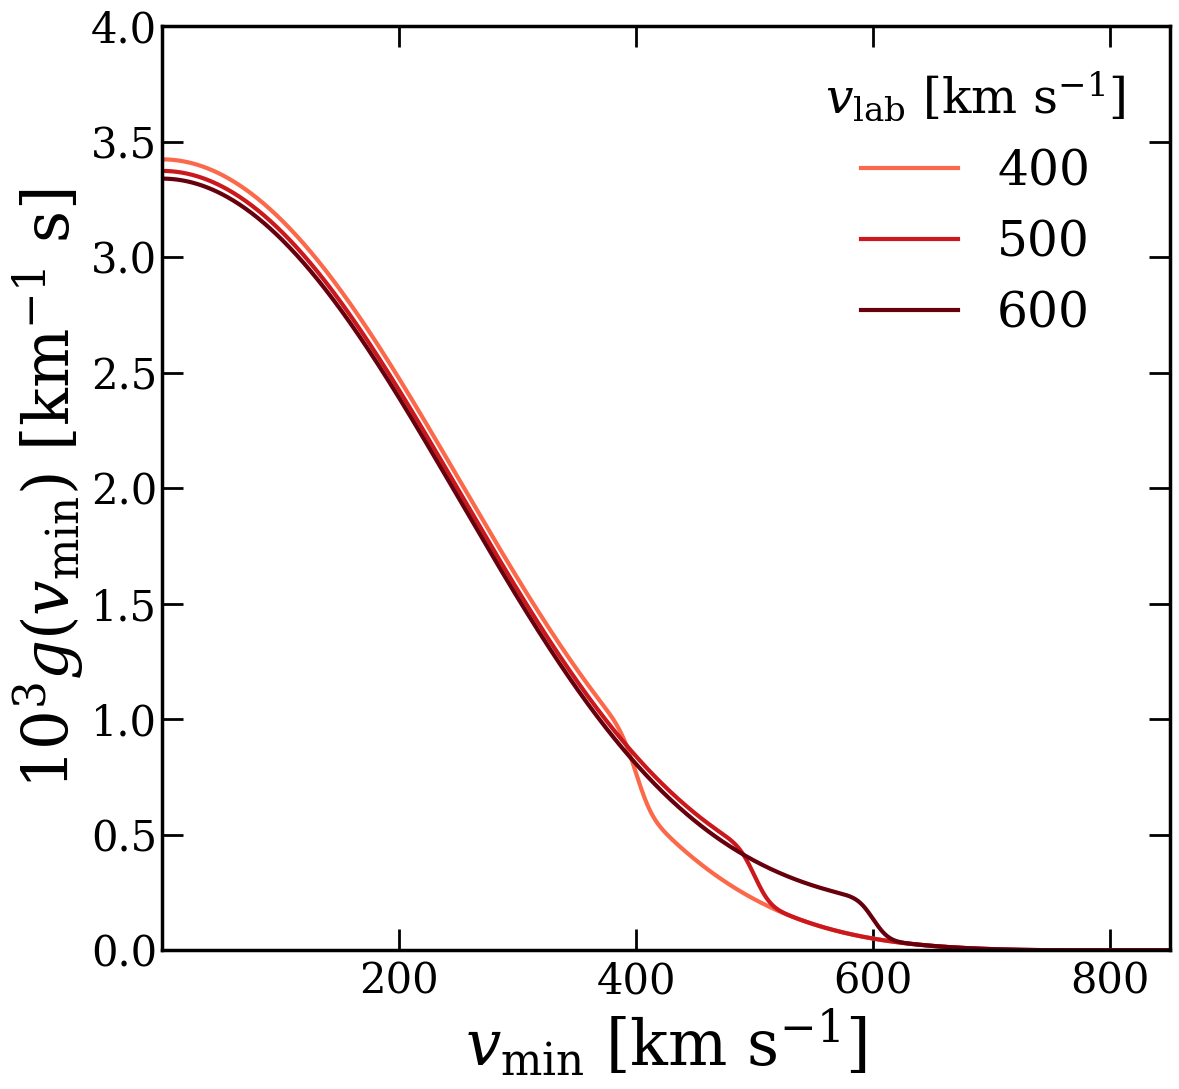

In [4]:
# Use an array of values for v_min to make the plot
v_min = linspace(0.01,850.0,1000)
#the v function here is interchangable with the other one from the first try:
for v_lab,col in zip([400,500,600],cm.Reds([0.5,0.75,1.0])):
    plt.plot(v_min,1e3*g(v_min, v_lab_dependency=v_lab),'-',color=col,label=str(v_lab))

plt.xlabel(r'$v_{\rm min}$ [km s$^{-1}$]')
plt.ylabel(r'$10^3 g(v_{\rm min})$ [km$^{-1}$ s]')
plt.ylim(top=4)
plt.legend(title=r'$v_{\rm lab}$ [km s$^{-1}$]')

In [5]:
#random number reference function
import numpy as np
import random

random.seed(42)
density_vector = np.zeros(100)
for i in range(100):
    # Generating a random integer between 1 and 10
    random_integer = random.randint(1, 10)
    # Assigning the random integer to the array at index i
    density_vector[i] = random_integer
normalization_factor = 1/np.sum(density_vector)
density_vector_norm = normalization_factor*density_vector
print(np.sum(density_vector_norm))

1.0


In [6]:
import random
import numpy as np
import matplotlib.pyplot as plt

def g_new(v_min,Number,v_mean,sigma_mean):
    #this part makes the coefficient (density) vector normalized to 1 and we'll dot product to MIS vector dudeeee
    density_vector = np.zeros(Number) 
    for i in range(Number):
        #seed is unnecessary and can be removed soon
        random.seed(42) #here (optional)
        random_integer = random.randint(1, 10) #arbitrary interval for random number at larger values of N, it might be better to change the random to a continuous interval from 0-1
        density_vector[i] = random_integer
        
    normalization_factor = 1/np.sum(density_vector)
    density_vector_norm = normalization_factor*density_vector #This is the normalized density vector

    #this is the part for the function for the MIS vector
    g = density_vector_norm[Number-1] * MeanInverseSpeed(v_min)
    #v_mean = 500 # i think this is supposed to be the mean velocity of the stream so i think like v_lab
    std_dev_vel = 100
    std_dev_sigma = 5
    for i in range(Number-1): #N-1 because we already have the first term when we initialized the MIS above
        random_velocity = np.random.normal(v_mean, std_dev_vel, 1)
        random_sigma = np.random.normal(sigma_mean, std_dev_sigma, 1)
        if random_sigma[0] <= 0:
            random_sigma[0] = 1e-29
        j = density_vector_norm[i] * MeanInverseSpeed(v_min, v_lab=random_velocity[0], sig_v=random_sigma[0])
        g += j
    return g

In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

#-------------------- Mean Inverse Speed (for Gaussian f(v)) --------------------------#

def MeanInverseSpeed(v_min,sig_v=167.0,v_esc=533.0,v_lab=245.6):
    N_esc = erf(v_esc/(sqrt(2.0)*sig_v))\
            -sqrt(2.0/pi)*(v_esc/sig_v)*exp(-v_esc**2.0/(2.0*sig_v**2.0))
    
    # Define:
    v_0 = sig_v*sqrt(2.0)
    x = v_min/v_0
    z = v_esc/v_0
    y = v_lab/v_0
    
    # Set up conditional terms
    g = zeros_like(v_min)
    g[(x<abs(y-z))&(z<y)] = (1.0/(v_0*y))
    g2 = (1.0/(2.0*N_esc*v_0*y))*(erf(x+y)-erf(x-y)-(4.0/sqrt(pi))*y*exp(-z**2))
    g3 = (1.0/(2.0*N_esc*v_0*y))*(erf(z)-erf(x-y)-(2.0/sqrt(pi))*(y+z-x)*exp(-z**2))
    
    # Apply conditions
    g[(x<abs(y-z))&(z>y)] = g2[(x<abs(y-z))&(z>y)]
    g[(abs(y-z)<x)&(x<(y+z))] = g3[(abs(y-z)<x)&(x<(y+z))]
    g[(y+z)<x] = 0.0
    
    return g


#This is the new improved function with no nested for-loops
def g_new2(v_min,Number,v_mean,sigma_mean):
    # Initializing the array containing the random velocity, sigma, and density (normalized) values
    random_velocity = np.random.normal(v_mean, 100, Number)
    random_sigma = np.random.normal(sigma_mean, 5, Number)
    random_density = np.random.rand(Number)
    random_density_normalized = random_density * 1/np.sum(random_density)

    # Combine the arrays into a 2D array
    random_array = np.column_stack((random_velocity, random_sigma, random_density_normalized))
    # Now, random_array is a 2D array with shape (Number, 3)
    MIS = np.zeros((Number, len(v_min)))
    for i in range(Number):
        MIS[i, :] = random_array[i, 2] * MeanInverseSpeed(v_min, sig_v=random_array[i, 1], v_lab=random_array[i, 0])
    GMIS = np.sum(MIS, axis=0)

    return GMIS



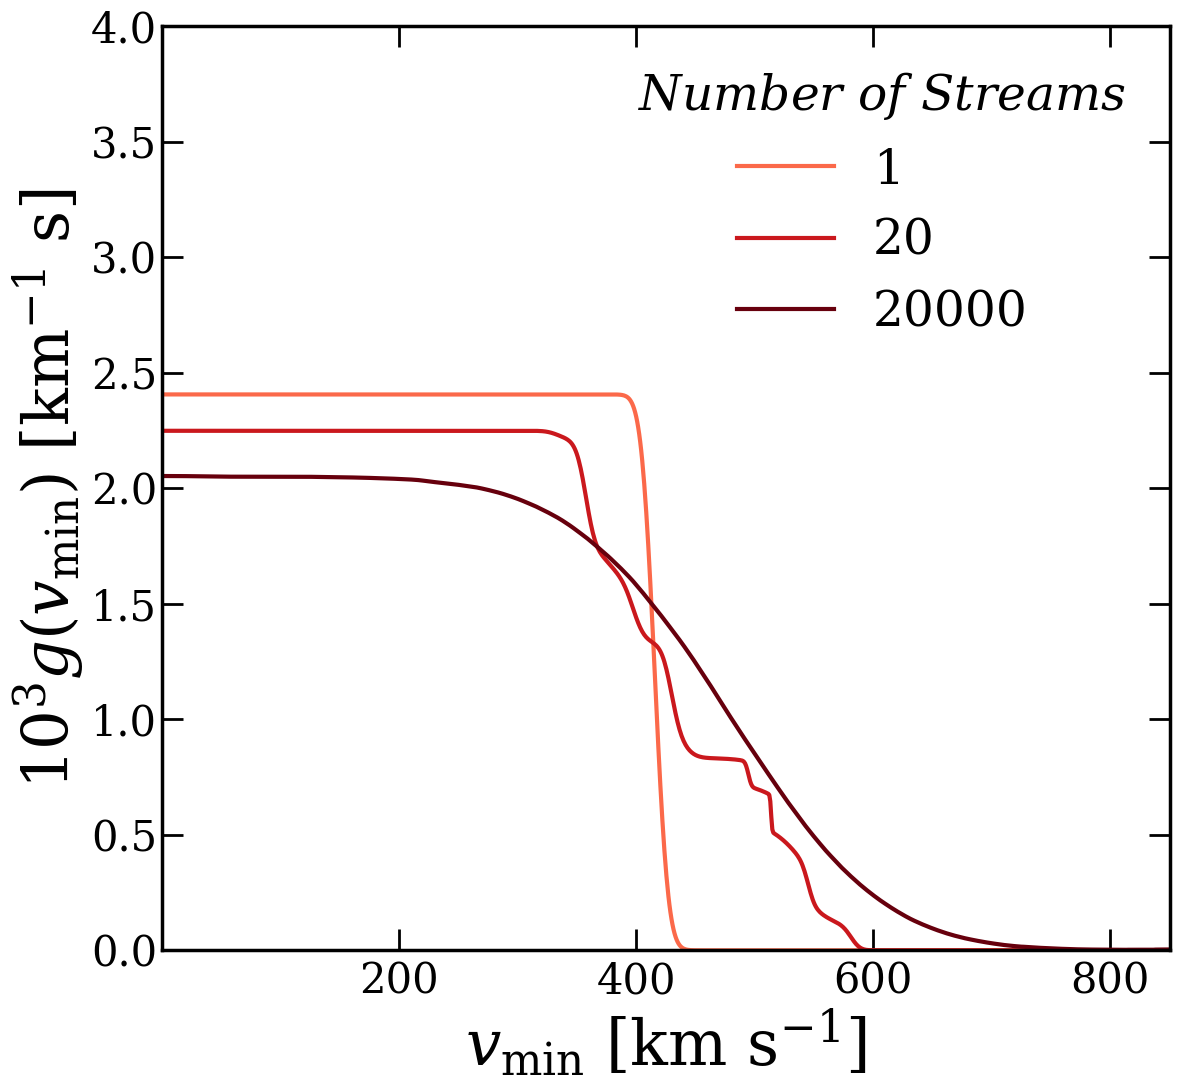

In [8]:
import matplotlib.pyplot as plt
from numpy import linspace
#v_min = linspace(0.01,850.0,1000)
#plt.plot(v_min,1e3*g(v_min,N=2,v_mean=500))

for Number,col in zip([1,20,20000],cm.Reds([0.5,0.75,1.0])):
    plt.plot(v_min, 1e3 * g_new2(v_min, Number, v_mean = 500, sigma_mean = 10), '-', color=col, label=str(Number))

plt.xlabel(r'$v_{\rm min}$ [km s$^{-1}$]')
plt.ylabel(r'$10^3 g(v_{\rm min})$ [km$^{-1}$ s]')
plt.ylim(top=4)
plt.legend(title=r'$Number$ $of$ $Streams$')

In [9]:
import numpy as np
import matplotlib.pyplot as plt

std_dev_sigma = 5
sigma_mean = 10

# Initialize random_sigma with values less than or equal to zero to enter the loop
random_sigma = np.random.normal(sigma_mean, std_dev_sigma, 1000)

while np.any(random_sigma <= 0):
    # Keep sampling until all values are valid
    random_sigma = np.random.normal(sigma_mean, std_dev_sigma, 1000)

# Now random_sigma is guaranteed to have all values greater than zero

# Plot the histogram
plt.hist(random_sigma, bins=30, density=True, alpha=0.7, color='blue')
plt.title('Random Sigma from Gaussian Distribution')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.show()

KeyboardInterrupt: 

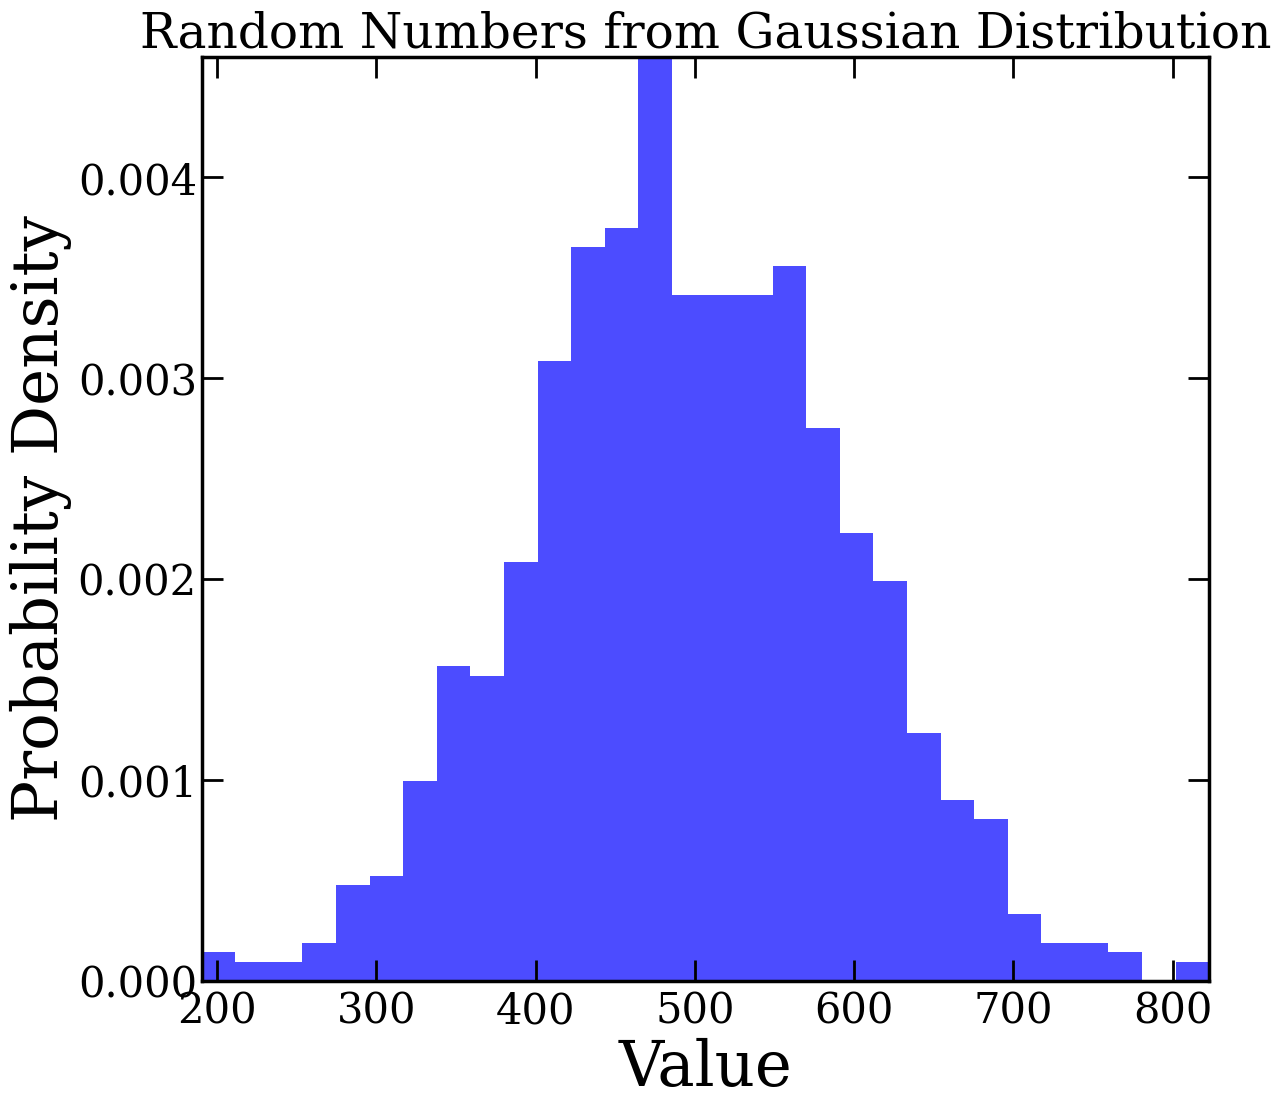

In [10]:
#just for reference
import numpy as np
import matplotlib.pyplot as plt

# Set the mean and standard deviation
mean = 500
std_dev = 100

# Generate random numbers following a Gaussian distribution
num_samples = 1000
random_numbers = np.random.normal(mean, std_dev, num_samples)

plt.hist(random_numbers, bins=30, density=True, alpha=0.7, color='blue')
plt.title('Random Numbers from Gaussian Distribution')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.show()

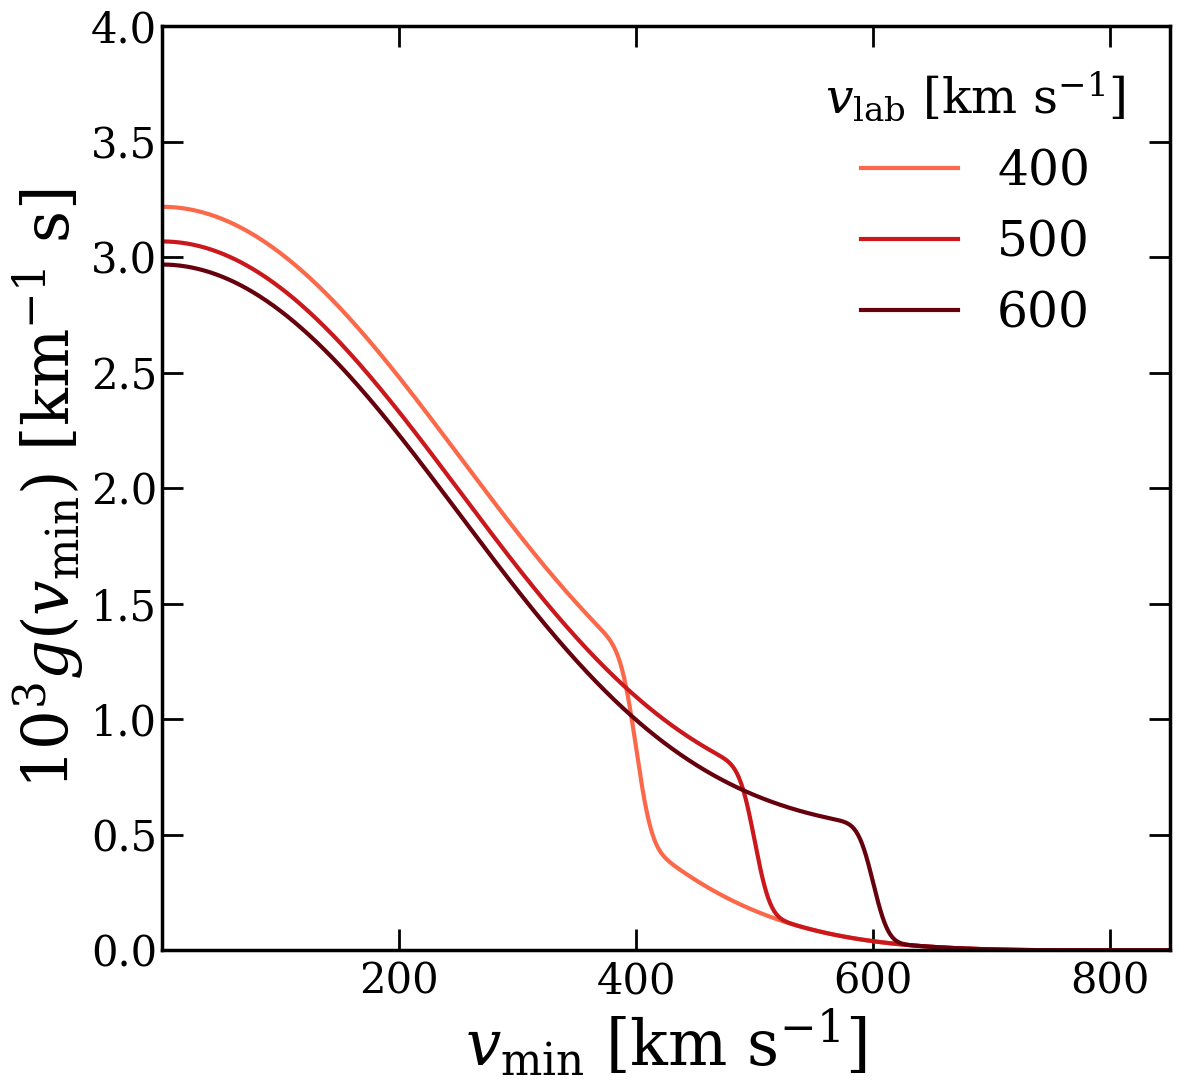

In [11]:
#here i am just changing the sample g function from before where ive added dependence on the v_lab and am planning to add dependence 
def g(v_min, v_lab_dependency,R):
    return R * MeanInverseSpeed(v_min) + (1-R) * MeanInverseSpeed(v_min, v_lab=v_lab_dependency, sig_v=10.0)





# Use an array of values for v_min to make the plot
v_min = linspace(0.01,850.0,1000)
#the v function here is interchangable with the other one from the first try:
for v_lab,col in zip([400,500,600],cm.Reds([0.5,0.75,1.0])):
    plt.plot(v_min,1e3*g(v_min, v_lab_dependency=v_lab,R=0.7),'-',color=col,label=str(v_lab))

plt.xlabel(r'$v_{\rm min}$ [km s$^{-1}$]')
plt.ylabel(r'$10^3 g(v_{\rm min})$ [km$^{-1}$ s]')
plt.ylim(top=4)
plt.legend(title=r'$v_{\rm lab}$ [km s$^{-1}$]')

## The next ingredient we need is something called the "Form factor"
This is another slightly obscure thing, but what it entails is the stcuture of the nucleus. Essentially the internal structure of the nucleus becomes more important when the interactions are at higher energies. If the collision has a low energy then the DM particle essentially interacts with the "whole" nucleus coherently. But if the energy is high, the interaction starts to see the individual nucleons. So the form factor is a function that describes how that happens.

We'll be using an ansatz called the "Helm form factor" which is a dimensionless function $F(E_r)$ where $E_r$ is the recoil energy
\begin{equation}
F\left(E_{r}\right)=\frac{3 j_{1}\left(q r_{1}\right)}{\left(q r_{1}\right)^{3}} e^{-q^{2} s^{2}}
\end{equation}
the size of the nucleus is parameterised as,
\begin{equation}
r_{1}=\sqrt{c^{2}+\frac{7}{3} \pi^{2} a^{2}-5 s^{2}}
\end{equation}
where $a = 0.52$ fm, $s=0.9$ fm are fitting parameters, and $c=\left(1.23 A^{1 / 3}-0.6\right)$ for a nucleus with mass number $A$. For xenon we will set $A=131$.

Note that in the scattering rate formula we use the form factor squared, $F^2(E_r)$


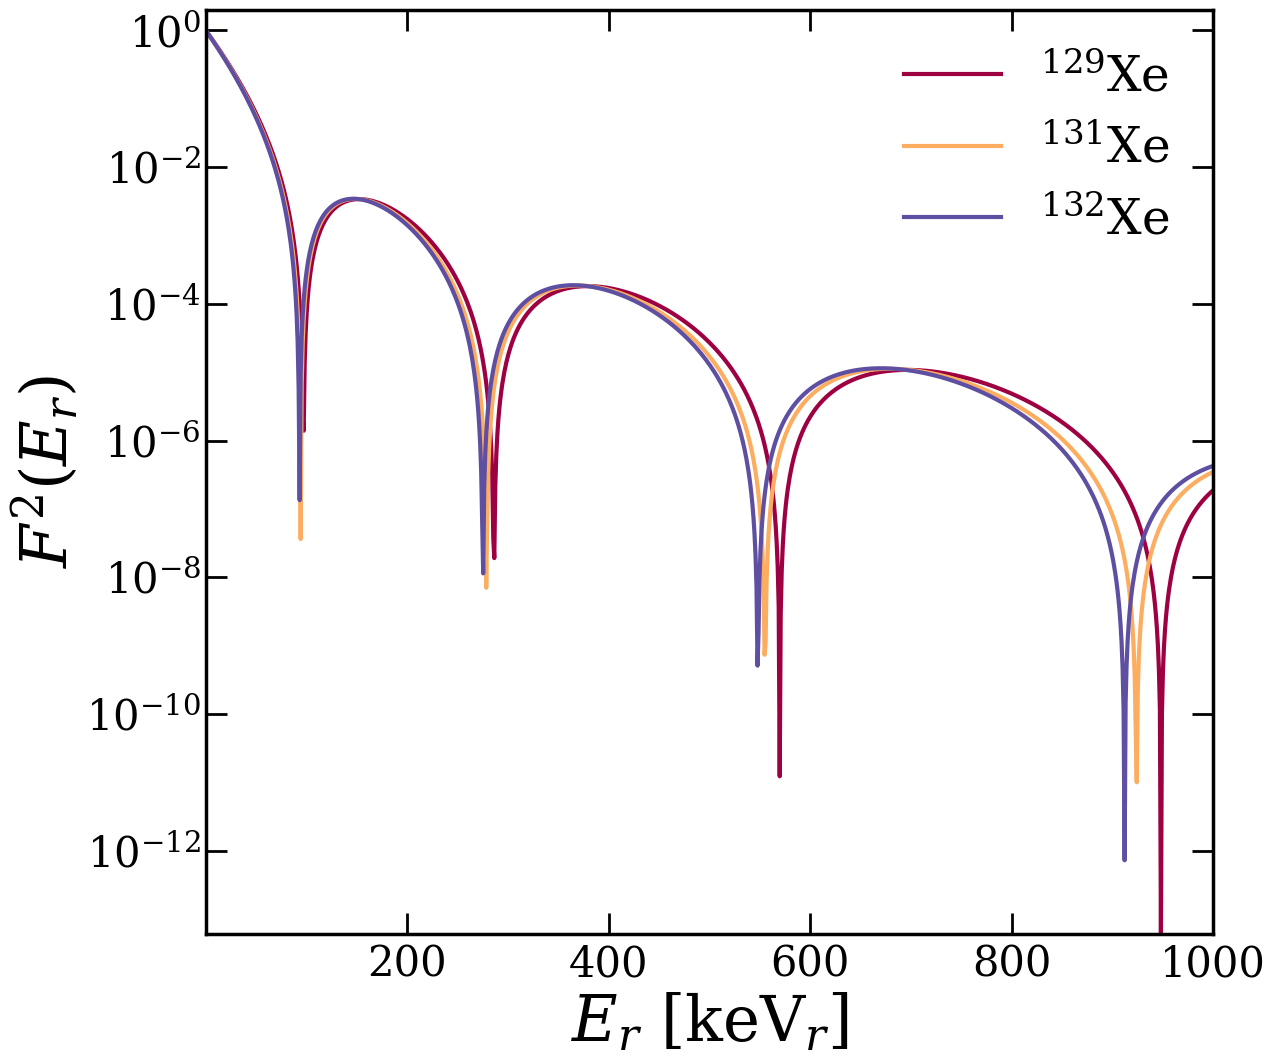

In [12]:
#--------------------Helm Form Factor-------------------------------------------#
def FormFactorHelm(E_r,A):
    # Momentum transfer in fm^-1
    q = sqrt(2*A*931.5*1000*E_r)*1.0e-12/1.97e-7 # q = sqrt(2 m_N E_r)

    c1 = 1.23*A**(1.0/3.0)-0.6
    s = 0.9
    r_1 = sqrt(c1**2 + (7.0/3.0)*pi**2.0*(0.52**2.0) - 5*s**2.0)
    F = (3*(sin(q*r_1) - q*r_1*cos(q*r_1))*exp(-q*q*s*s/2.0)/(q*r_1)**3)
    return F

# Set a range of energies to do the plot
E_r = linspace(0.1,1000.0,1000)

# Plot the form factor squared or a few isotopes of xenon
for (A,col,lab) in zip([129,131,132],cm.Spectral([0.0,0.3,1.0]),[r'$^{129}$Xe',r'$^{131}$Xe',r'$^{132}$Xe']):
    plt.semilogy(E_r,FormFactorHelm(E_r,A)**2,label=lab,color=col)
    
plt.legend()
plt.ylabel(r'$F^2(E_r)$')
plt.xlabel(r'$E_r$ [keV$_r$]')
plt.ylim(top=2);

# Now we can start to look at the rate
A function we need to define first are the minimum WIMP speed that can cause a recoil energy $E_r$
\begin{equation}
v_{\min }=\sqrt{\frac{m_{N} E_{r}}{2 \mu_{\chi N}}}
\end{equation}
where $\mu_{\chi N} = m_\chi m_N/(m_\chi + m_N)$ for a nucleus of mass $m_N \approx A m_p$.

In [13]:
def MinimumWIMPSpeed(E_r,A,m_chi,delta=0):
    # E_r = recoil energy in keVr
    # A = nucleus mass number
    # m_chi = WIMP mass in GeV
    # delta = for inelastic scattering
    m_N_keV = A*m_p_keV # nucleus mass in keV
    mu_N_keV = 1.0e6*m_chi*m_N_keV/(1.0e6*m_chi + m_N_keV) # reduced nucleus mass
    v_min = sqrt(1.0/(2*m_N_keV*E_r))*(m_N_keV*E_r/mu_N_keV + delta)*c_km
    return v_min

# The spin independent differential recoil rate
For spin-independent scattering we have two free parameters the DM mass $m_\chi$ and the total proton cross section $\sigma^{\rm SI}_p$ (we assume equal proton and neutron couplings). The formula looks like this:

\begin{equation}
\frac{\mathrm{d}R}{\mathrm{d} E_{r}}= \frac{\rho_{0}}{2 \mu_{\chi p}^{2} m_{\chi}} \sigma_{p}^{\mathrm{SI}} A^2 \,
F^{2}(E_{r})\, g(v_{\min })
\end{equation}
where
* $\rho_0 = 0.3$ GeV/cm$^3$ is the DM density around us
* $E_r$ is the recoil energy (usually expressed in units of keV)
* $\mu_{\chi p} = m_\chi m_p/(m_\chi + m_p)$ is called the "WIMP-proton reduced mass"
* $ A \approx 131$ is the nucleus mass number
* $v_{\rm min}$ is the minimum DM speed that can cause a recoil with energy $E_r$. Note that this means that our $g(v_{\rm min})$ function is therefore effecively a function of $E_r$

<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Wayne Pooley\AppData\Local\Temp\ipykernel_17248\1186040153.py:43: SyntaxWarning: invalid escape sequence '\c'
  plt.legend(title='$m_\chi$ [GeV]',loc='lower left')


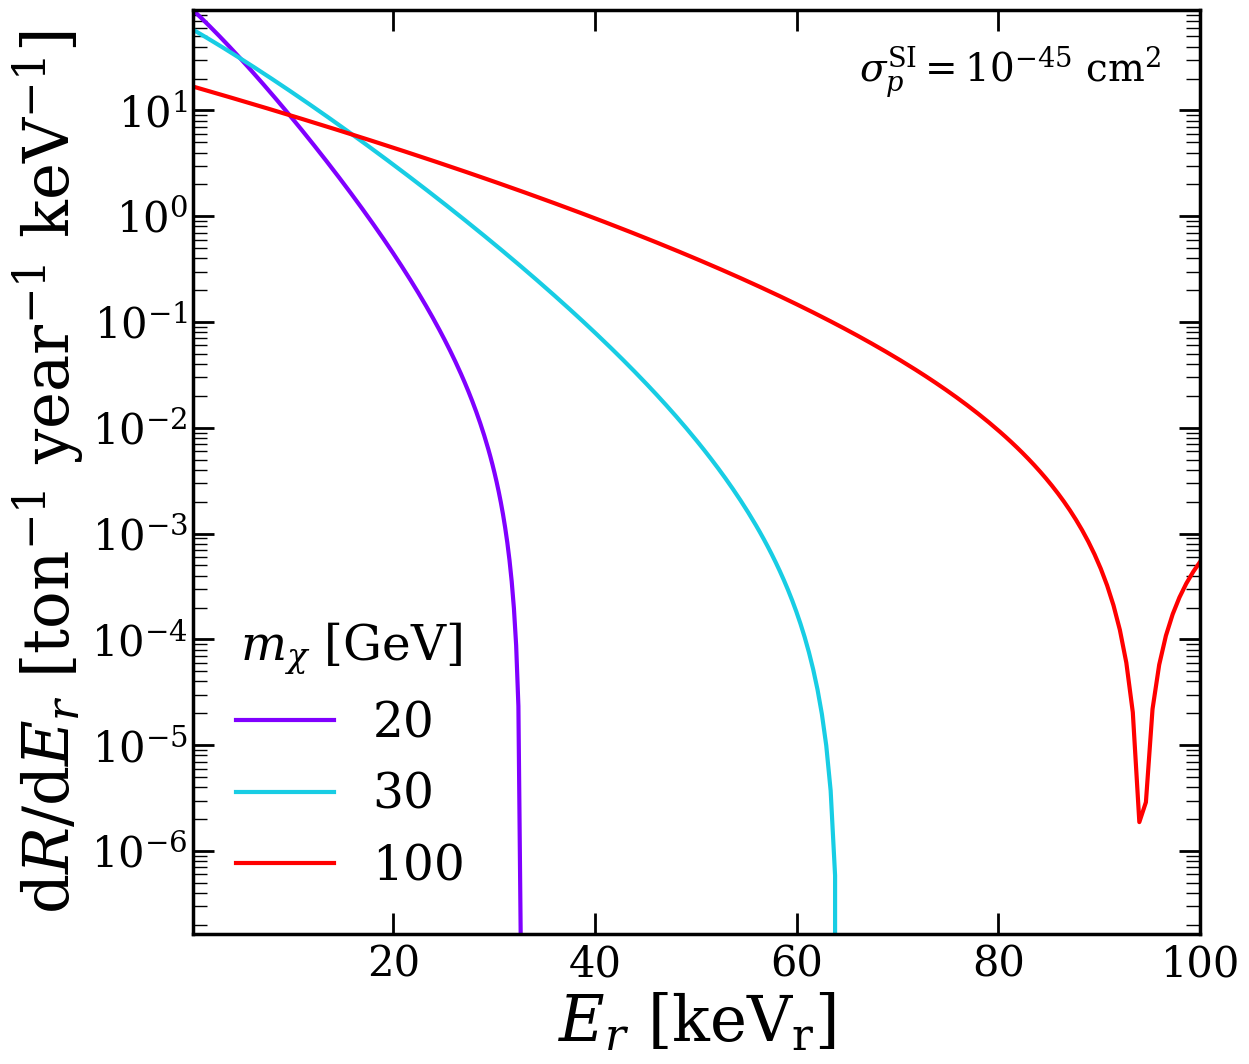

In [14]:
def dRdE_SI(E_r,m_chi,sigma_p,A,gvmin_function,rho_0=0.3):
    '''
    * Spin independent differentual recoil rate that takes in recoil energy in 
    units of keV and a proton cross section in units of cm^2 and outputs a rate
    in units of (ton year keVr)^-1
    
    * gvmin_function should be a function that takes in v_min in (km/s) and outputs
    g(v_min) in units of (km/s)^-1
    '''
    
    # DM-proton reduced mass (in units of keV)
    mu_p = 1.0e6*m_chi*m_p_keV/(1.0e6*m_chi + m_p_keV)
    
    # Rate constants (in units cm kg^-1 s^-2)
    R0 = (c_cm**2)*((rho_0*1.0e6*A**2*sigma_p)/(2*m_chi*GeV_2_kg*mu_p**2)) 

    # Mean inverse speed
    v_min = MinimumWIMPSpeed(E_r,A,m_chi)
    g = gvmin_function(v_min)/(1000.0*100.0) # convert to cm^-1 s

    # Compute rate = (Rate amplitude * gmin * form factor)
    FF = FormFactorHelm(E_r,A)**2.0
    dR = R0*g*FF
    dR = dR*seconds2year*1000.0 # convert to (ton-year-keV)^-1
    return dR

# Define a range of energies to do the plot, we make this logarithmically spaced because the rate is exponentially falling
E_r = logspace(-1,2,1000)

# Define g(vmin) as an inline function
g = lambda v_min : MeanInverseSpeed(v_min)

# Define our parameters
sigma_p = 1.0e-45
A = 131

# Plot a few example DM masses
for m_chi,col in zip([20,30,100],cm.rainbow([0.0,0.3,1.0])):
    plt.semilogy(E_r,dRdE_SI(E_r,m_chi,sigma_p,A,g),color=col,label=str(m_chi))

plt.xlabel(r'$E_r$ [keV$_{\rm r}$]')
plt.ylabel(r'd$R$/d$E_r$ [ton$^{-1}$ year$^{-1}$ keV$^{-1}$]')
plt.legend(title='$m_\chi$ [GeV]',loc='lower left')
plt.gcf().text(0.87,0.82,r'$\sigma^{\rm SI}_p = 10^{-45}$ cm$^2$',ha='right');
plt.xlim(right=amax(E_r));

The script below contains the possibly botched information of the modified dR/dE_r equation with the inclusion of the modified g(vmin) function

<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Wayne Pooley\AppData\Local\Temp\ipykernel_17248\748158678.py:43: SyntaxWarning: invalid escape sequence '\c'
  plt.legend(title='$m_\chi$ [GeV]',loc='lower left')


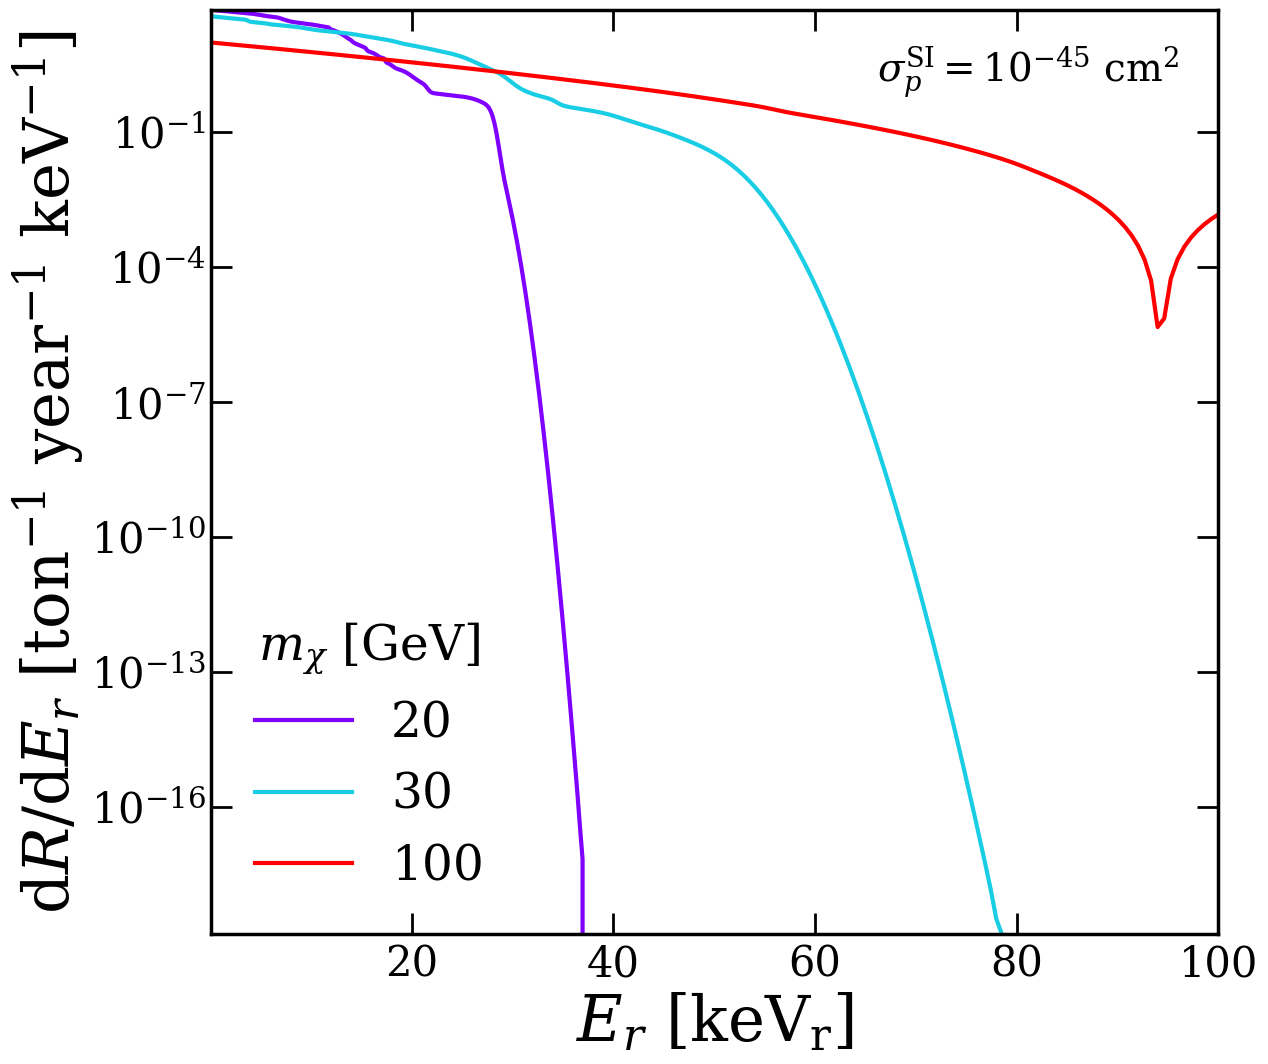

In [16]:
def dRdE_SI_new(E_r,m_chi,sigma_p,A,gvmin_function,rho_0=0.3):
    '''
    * Spin independent differentual recoil rate that takes in recoil energy in 
    units of keV and a proton cross section in units of cm^2 and outputs a rate
    in units of (ton year keVr)^-1
    
    * gvmin_function should be a function that takes in v_min in (km/s) and outputs
    g(v_min) in units of (km/s)^-1
    '''
    
    # DM-proton reduced mass (in units of keV)
    mu_p = 1.0e6*m_chi*m_p_keV/(1.0e6*m_chi + m_p_keV)
    
    # Rate constants (in units cm kg^-1 s^-2)
    R0 = (c_cm**2)*((rho_0*1.0e6*A**2*sigma_p)/(2*m_chi*GeV_2_kg*mu_p**2)) 

    # Mean inverse speed
    v_min = MinimumWIMPSpeed(E_r,A,m_chi)
    g = gvmin_function(v_min)/(1000.0*100.0) # convert to cm^-1 s

    # Compute rate = (Rate amplitude * gmin * form factor)
    FF = FormFactorHelm(E_r,A)**2.0
    dR = R0*g*FF
    dR = dR*seconds2year*1000.0 # convert to (ton-year-keV)^-1
    return dR

# Define a range of energies to do the plot, we make this logarithmically spaced because the rate is exponentially falling
E_r = logspace(-1,2,1000)

# Define g(vmin) as an inline function
g = lambda v_min : g_new2(v_min, Number=40, v_mean = 500, sigma_mean = 10)

# Define our parameters
sigma_p = 1.0e-45
A = 131

# Plot a few example DM masses
for m_chi,col in zip([20,30,100],cm.rainbow([0.0,0.3,1.0])):
    plt.semilogy(E_r,dRdE_SI_new(E_r,m_chi,sigma_p,A,g),color=col,label=str(m_chi))

plt.xlabel(r'$E_r$ [keV$_{\rm r}$]')
plt.ylabel(r'd$R$/d$E_r$ [ton$^{-1}$ year$^{-1}$ keV$^{-1}$]')
plt.legend(title='$m_\chi$ [GeV]',loc='lower left')
plt.gcf().text(0.87,0.82,r'$\sigma^{\rm SI}_p = 10^{-45}$ cm$^2$',ha='right');
plt.xlim(right=amax(E_r));


#see how you can modify this to make this a predefined random_array for the g(vmin) function so it doesnt loop this all the time when performing the for loop in the numberofevents function below

# To get the total number of expected events we need to integrate the rate over energy between some minimum and maximum energy 
Let's look at the result of this integration as a function of the DM mass.  The number of events the detector observes is the following:

\begin{equation}
N = M T \int_{E_{\rm th}}^{E_{\rm max}} \frac{dR}{dE_r} dE_r
\end{equation}
where $M$ is the mass of the detector and $T$ is how long we run it for. Usually we combine $MT$ together and quote an "exposure" in units of ton-years

We won't expect to have a nonzero number of events down to arbitrarily small masses because eventually there will be no DM particles fast enough to produce recoils scattering with $E_r>E_{\rm th}$. So there will be a minimum value of $m_\chi$ that the experiment can detect.


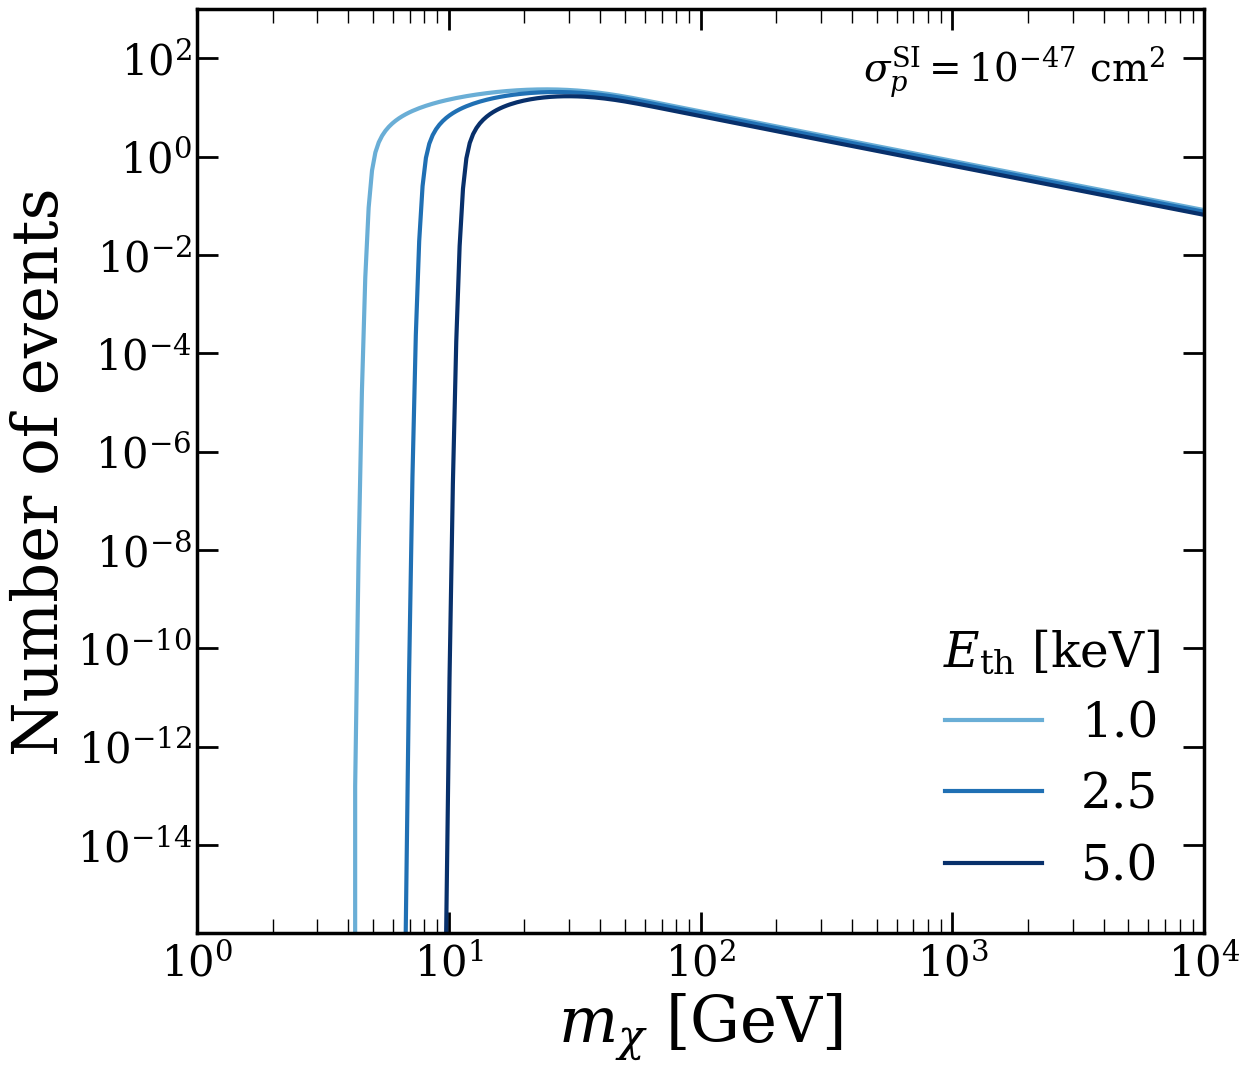

In [17]:
def NumberofEvents(dR_function,Exposure,E_th,E_max,npoints=10000): #original
    # This function integrates a provided dR/dE function between E_th and E_max
    E_r = linspace(E_th,E_max,npoints)
    N = trapz(dR_function(E_r),E_r)*Exposure # Multiply by exposure to get the total number of events
    return N


# Define some parameters
E_max = 100.0
A = 131
Exposure = 5.0 # ton-year
sigma_ref = 1.0e-47

nm = 300
m_chi_vals = logspace(0,4,nm)
g = lambda v_min : MeanInverseSpeed(v_min, sig_v=10, v_lab=500)

for E_th,col in zip([1.0,2.5,5.0],cm.Blues([0.5,0.75,1.0])):
    N = zeros_like(m_chi_vals)
    for i in range(0,nm):
        dR = lambda E_r : dRdE_SI(E_r,m_chi_vals[i],sigma_ref,A,g)
        N[i] = NumberofEvents(dR,Exposure,E_th,E_max)
    plt.loglog(m_chi_vals,N,color=col,label=str(E_th))

plt.legend(title=r'$E_{\rm th}$ [keV]',loc='lower right')
plt.xlabel(r'$m_\chi$ [GeV]')
plt.ylabel(r'Number of events')
plt.gcf().text(0.87,0.82,r'$\sigma^{\rm SI}_p = 10^{-47}$ cm$^2$',ha='right');
plt.ylim(top=1e3);

In [18]:
def g_new3(v_min,Number,v_mean,sigma_mean): #reference this is the function where we initalize outside the for loops
       # Combine the arrays into a 2D array
    random_array = np.column_stack((random_velocity, random_sigma, random_density_normalized))
    # Now, random_array is a 2D array with shape (Number, 3)
    MIS = np.zeros((Number, len(v_min)))
    for i in range(Number):
        MIS[i, :] = random_array[i, 2] * MeanInverseSpeed(v_min, sig_v=random_array[i, 1], v_lab=random_array[i, 0])
    GMIS = np.sum(MIS, axis=0)

    return GMIS

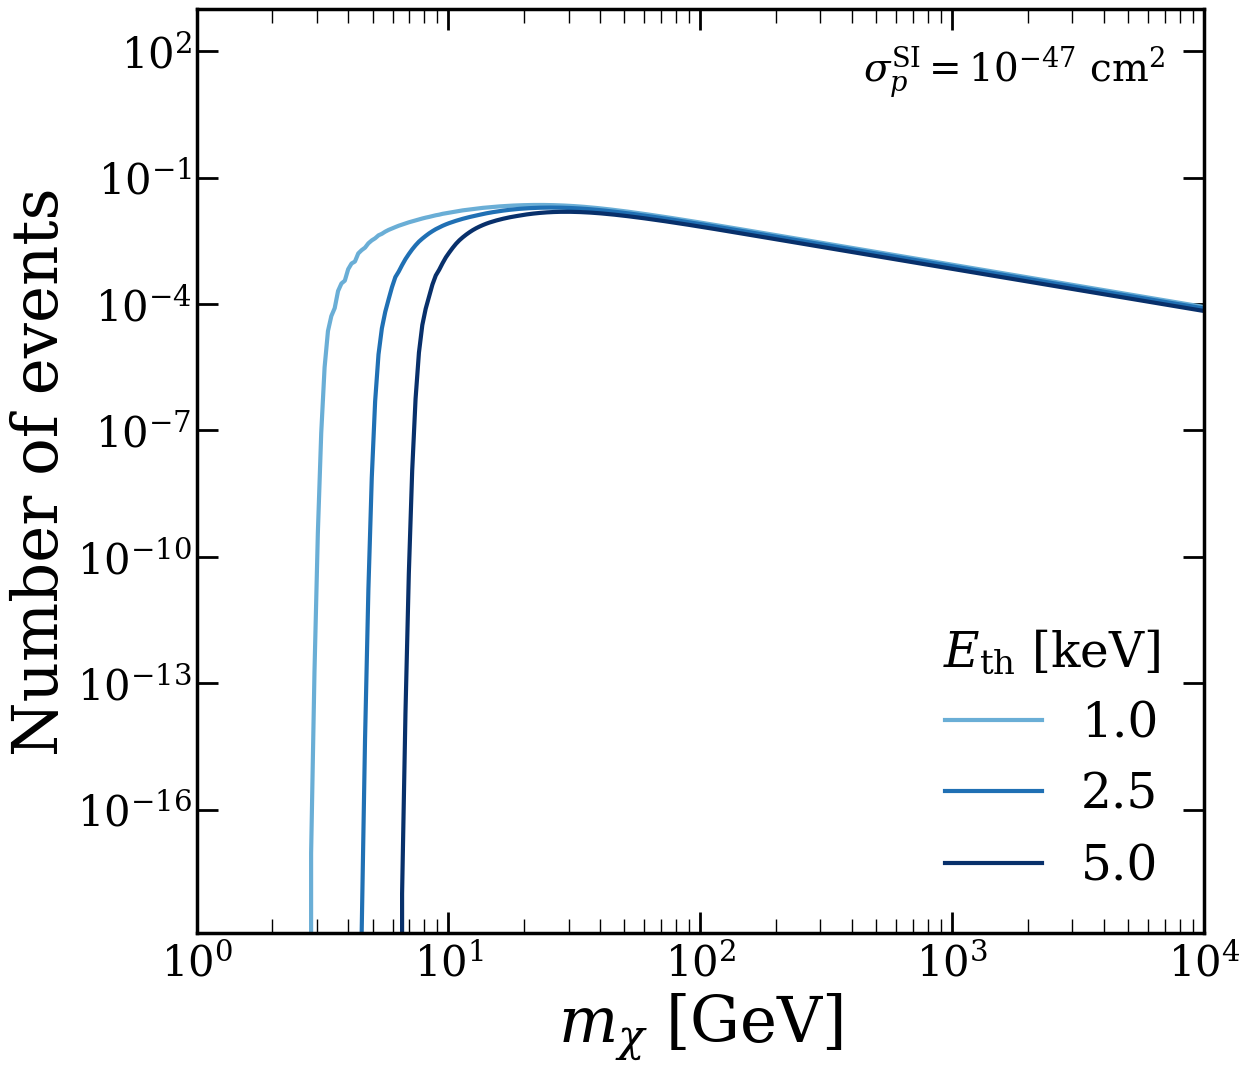

In [22]:
#Initializing the array containing the random velocity, sigma, and density (normalized) values
random_velocity = np.random.normal(v_mean, 100, Number)
random_sigma = np.random.normal(sigma_mean, 5, Number)
random_density = np.random.rand(Number)
random_density_normalized = random_density * 1/np.sum(random_density)


def dRdE_SI_new_2(E_r,m_chi,sigma_p,A,gvmin_function,rho_0=0.3):
    '''
    * Spin independent differentual recoil rate that takes in recoil energy in 
    units of keV and a proton cross section in units of cm^2 and outputs a rate
    in units of (ton year keVr)^-1
    
    * gvmin_function should be a function that takes in v_min in (km/s) and outputs
    g(v_min) in units of (km/s)^-1
    '''
    
    # DM-proton reduced mass (in units of keV)
    mu_p = 1.0e6*m_chi*m_p_keV/(1.0e6*m_chi + m_p_keV)
    
    # Rate constants (in units cm kg^-1 s^-2)
    R0 = (c_cm**2)*((rho_0*1.0e6*A**2*sigma_p)/(2*m_chi*GeV_2_kg*mu_p**2)) 

    # Mean inverse speed
    v_min = MinimumWIMPSpeed(E_r,A,m_chi)
    g = gvmin_function(v_min)/(1000.0*100.0) # convert to cm^-1 s

    # Compute rate = (Rate amplitude * gmin * form factor)
    FF = FormFactorHelm(E_r,A)**2.0
    dR = R0*g*FF
    dR = dR*seconds2year*1000.0 # convert to (ton-year-keV)^-1
    return dR

# Define a range of energies to do the plot, we make this logarithmically spaced because the rate is exponentially falling
E_r = logspace(-1,2,1000)

# Define g(vmin) as an inline function
g = lambda v_min : g_new3(v_min, Number=40, v_mean = 500, sigma_mean = 10)

# Define our parameters
sigma_p = 1.0e-45
A = 131




def NumberofEvents_2(dR_function,Exposure,E_th,E_max,npoints=500):
    # This function integrates a provided dR/dE function between E_th and E_max
    E_r = linspace(E_th,E_max,npoints)
    N = trapz(dR_function(E_r),E_r)*Exposure # Multiply by exposure to get the total number of events
    return N


# Define some parameters
E_max = 100.0
A = 131
Exposure = 5.0 # ton-year
sigma_ref = 1.0e-47

nm = 300
m_chi_vals = logspace(0,4,nm)

g = lambda v_min : g_new3(v_min, Number=20, v_mean = 500, sigma_mean = 50)


for E_th,col in zip([1.0,2.5,5.0],cm.Blues([0.5,0.75,1.0])):
    N = zeros_like(m_chi_vals)
    for i in range(0,nm):
        dR = lambda E_r : dRdE_SI_new(E_r,m_chi_vals[i],sigma_ref,A,g)
        N[i] = NumberofEvents_2(dR,Exposure,E_th,E_max)
    plt.loglog(m_chi_vals,N,color=col,label=str(E_th))

plt.legend(title=r'$E_{\rm th}$ [keV]',loc='lower right')
plt.xlabel(r'$m_\chi$ [GeV]')
plt.ylabel(r'Number of events')
plt.gcf().text(0.87,0.82,r'$\sigma^{\rm SI}_p = 10^{-47}$ cm$^2$',ha='right');
plt.ylim(top=1e3);



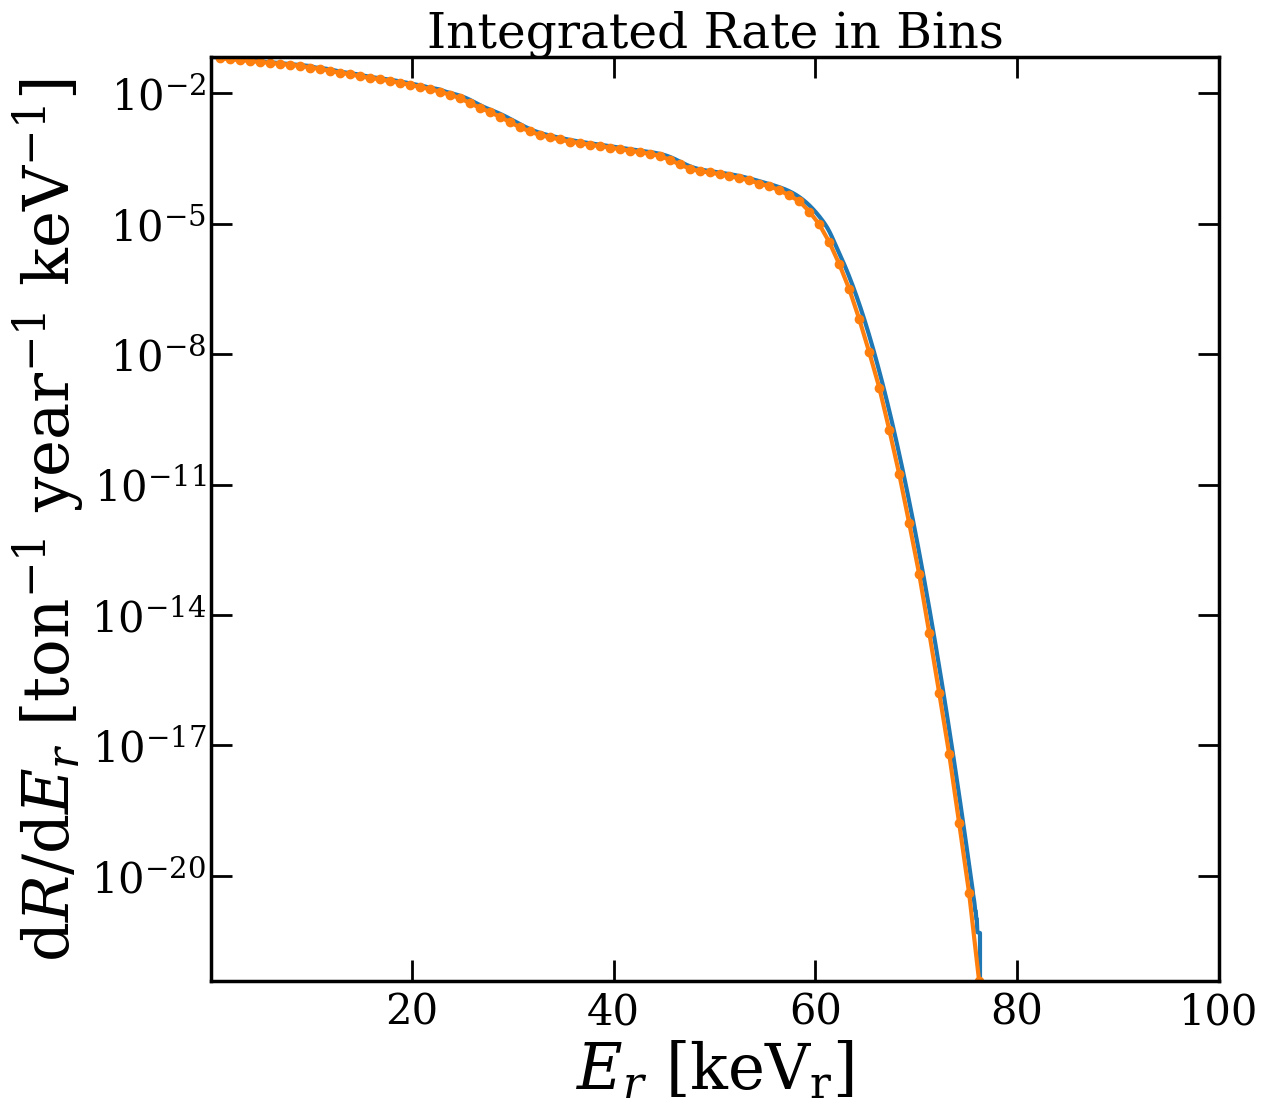

[ 6.35173096e-002  6.03992092e-002  5.75219719e-002  5.49190342e-002
  5.20676125e-002  4.96640636e-002  4.71877625e-002  4.47958824e-002
  4.25347548e-002  3.88800259e-002  3.61197492e-002  3.27434127e-002
  2.94591377e-002  2.73339717e-002  2.43849731e-002  2.24633693e-002
  2.08415068e-002  1.90749945e-002  1.72584710e-002  1.56599899e-002
  1.38582977e-002  1.24428893e-002  1.08200086e-002  9.21506040e-003
  7.72792282e-003  5.90265653e-003  4.62146412e-003  3.68581915e-003
  2.87718473e-003  2.15974005e-003  1.65621236e-003  1.32216821e-003
  1.09514930e-003  9.68294670e-004  8.66466030e-004  7.63768078e-004
  7.19186256e-004  6.45848854e-004  6.12184681e-004  5.63336315e-004
  5.18440790e-004  4.77718326e-004  4.40293291e-004  4.02068357e-004
  3.63790880e-004  2.93797749e-004  2.31704559e-004  1.84795720e-004
  1.60816008e-004  1.50836941e-004  1.36861324e-004  1.22635743e-004
  1.11618667e-004  9.90183811e-005  8.33416591e-005  7.23860449e-005
  5.86422026e-005  4.44364189e-005

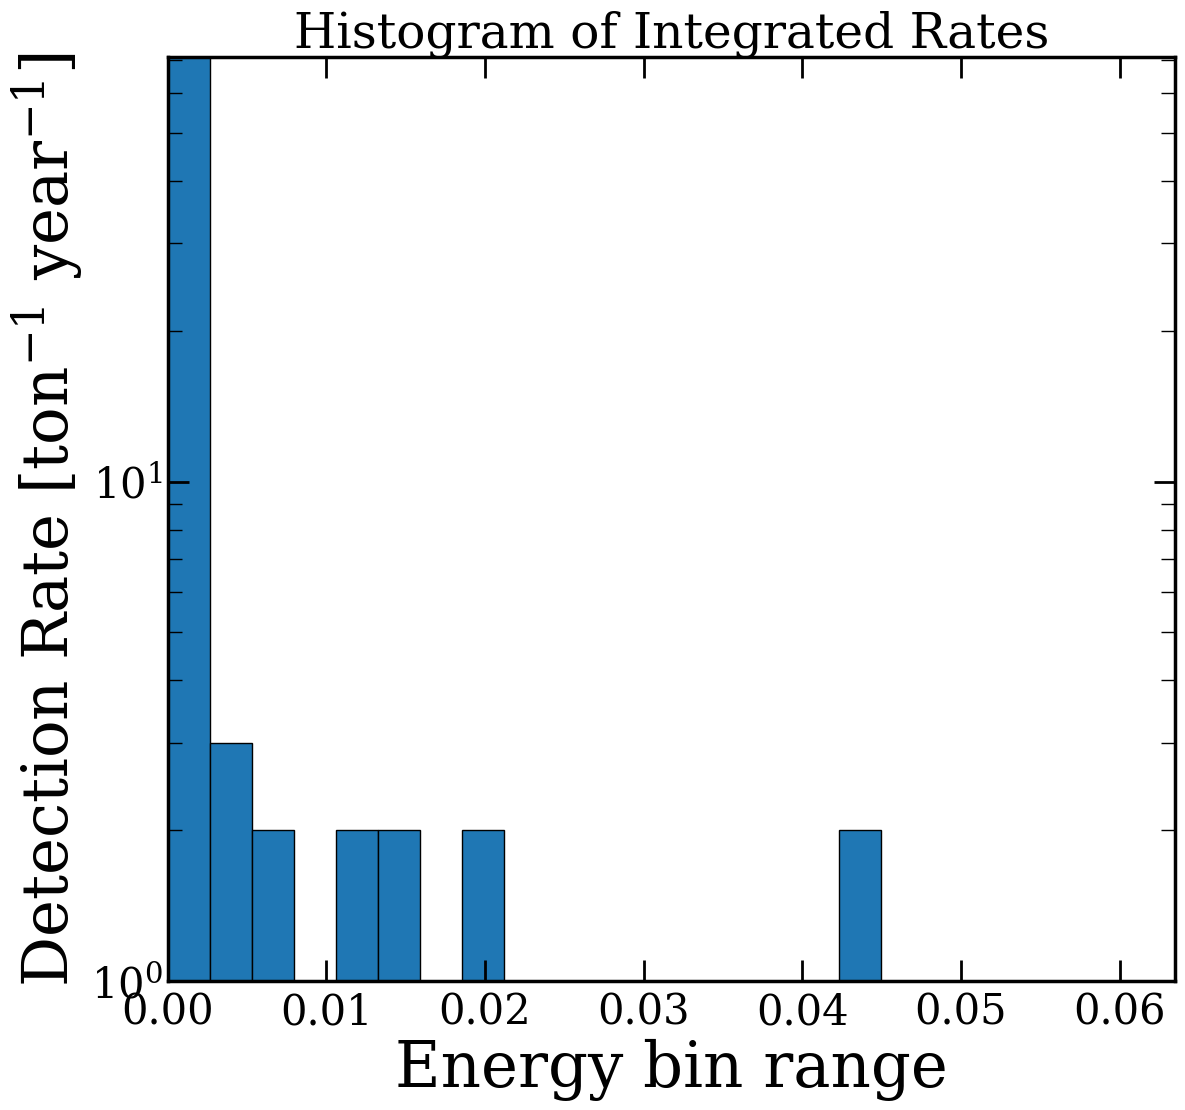

In [83]:
v_mean = 500
random_velocity = np.random.normal(v_mean, 100, Number)
random_sigma = np.random.normal(sigma_mean, 5, Number)
random_density = np.random.rand(Number)
random_density_normalized = random_density * 1/np.sum(random_density)


def dRdE_SI_new_2(E_r,m_chi,sigma_p,A,gvmin_function,rho_0=0.3):
    '''
    * Spin independent differentual recoil rate that takes in recoil energy in 
    units of keV and a proton cross section in units of cm^2 and outputs a rate
    in units of (ton year keVr)^-1
    
    * gvmin_function should be a function that takes in v_min in (km/s) and outputs
    g(v_min) in units of (km/s)^-1
    '''
    
    # DM-proton reduced mass (in units of keV)
    mu_p = 1.0e6*m_chi*m_p_keV/(1.0e6*m_chi + m_p_keV)
    
    # Rate constants (in units cm kg^-1 s^-2)
    R0 = (c_cm**2)*((rho_0*1.0e6*A**2*sigma_p)/(2*m_chi*GeV_2_kg*mu_p**2)) 

    # Mean inverse speed
    v_min = MinimumWIMPSpeed(E_r,A,m_chi)
    g = gvmin_function(v_min)/(1000.0*100.0) # convert to cm^-1 s

    # Compute rate = (Rate amplitude * gmin * form factor)
    FF = FormFactorHelm(E_r,A)**2.0
    dR = R0*g*FF
    dR = dR*seconds2year*1000.0 # convert to (ton-year-keV)^-1
    return dR

# Define a range of energies to do the plot, we make this logarithmically spaced because the rate is exponentially falling
E_r = logspace(-1,2,10000)

# Define g(vmin) as an inline function
g = lambda v_min : g_new3(v_min, Number=40, v_mean = 500, sigma_mean = 10)

# Define our parameters
sigma_p = 1.0e-45
A = 131

plt.semilogy(E_r, dRdE_SI_new_2(E_r, m_chi=30, sigma_p=sigma_p, A=A, gvmin_function=g))

#Now we will try to integrate over the differential

Bin_number = 100
Emin, Emax = 10e-1, 100
E_bin_edges =  linspace(Emin, Emax, Bin_number+1) #If we want 100 bins, then we need to define 101 bin edges.

#Initialize the vector for containing rates
Rates_vector = np.zeros(Bin_number)

for i in range(Bin_number):
    mask = (E_r >= E_bin_edges[i]) & (E_r < E_bin_edges[i + 1])
    Rates_vector[i] = trapz(dRdE_SI_new_2(E_r[mask], m_chi=30, sigma_p=sigma_p, A=A, gvmin_function=g), E_r[mask])

plt.plot(E_bin_edges[:-1], Rates_vector, marker='o')
plt.xlabel(r'$E_r$ [keV$_{\rm r}$]')
plt.ylabel(r'd$R$/d$E_r$ [ton$^{-1}$ year$^{-1}$ keV$^{-1}$]')
plt.title('Integrated Rate in Bins')
plt.show()

plt.hist(Rates_vector, bins='auto', edgecolor='black', log=True)  # 'auto' determines the number of bins automatically
print(Rates_vector)
# Customize the plot
plt.xlabel('Energy bin range')
plt.ylabel(r'Detection Rate [ton$^{-1}$ year$^{-1}$]')
plt.title('Histogram of Integrated Rates')

# Show the plot
plt.show()

3.821303843559879


(array([53.,  6.,  4.,  4.,  3.,  2.,  3.,  3.,  2.]),
 array([5.95023760e-07, 3.08087383e-02, 6.16168816e-02, 9.24250248e-02,
        1.23233168e-01, 1.54041311e-01, 1.84849455e-01, 2.15657598e-01,
        2.46465741e-01, 2.77273884e-01]),
 <BarContainer object of 9 artists>)

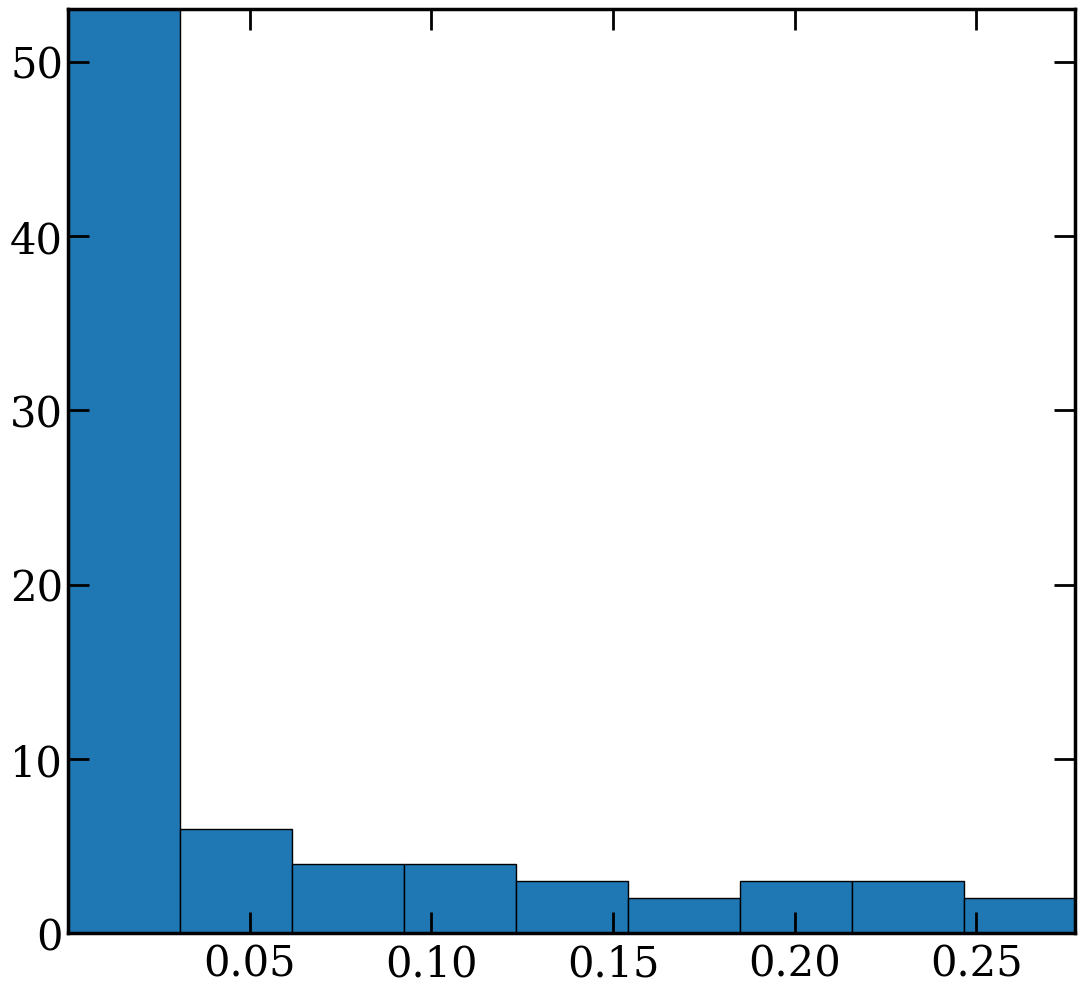

In [70]:
# Define a range of energies to do the plot, we make this logarithmically spaced because the rate is exponentially falling
E_r = logspace(-1,2,10000)

# Define g(vmin) as an inline function
g = lambda v_min : g_new3(v_min, Number=1, v_mean = 500, sigma_mean = 10)

# Define our parameters
sigma_p = 1.0e-45
A = 131

#plt.semilogy(E_r, dRdE_SI_new_2(E_r, m_chi=30, sigma_p=sigma_p, A=A, gvmin_function=g)) #hiding the plot for now

#Now we will try to integrate over the differential

Bin_number = 80 
Emin, Emax = 0, 50 #The range we are iterating over is values from 0 to 50
E_bin_edges =  linspace(Emin, Emax, Bin_number+1) #If we want 100 bins, then we need to define 101 bin edges.

#Initialize the vector for containing rates
Rates_vector1 = np.zeros(Bin_number)
for i in range(Bin_number):
    mask = (E_r >= E_bin_edges[i]) & (E_r < E_bin_edges[i + 1])
    Rates_vector1[i] = trapz(dRdE_SI_new_2(E_r[mask], m_chi=30, sigma_p=sigma_p, A=A, gvmin_function=g), E_r[mask])

g = lambda v_min : g_new3(v_min, Number=500, v_mean = 500, sigma_mean = 10)

Rates_vector2 = np.zeros(Bin_number)
for i in range(Bin_number):
    mask = (E_r >= E_bin_edges[i]) & (E_r < E_bin_edges[i + 1])
    Rates_vector2[i] = trapz(dRdE_SI_new_2(E_r[mask], m_chi=30, sigma_p=sigma_p, A=A, gvmin_function=g), E_r[mask])

#print(Rates_vector1)
#print(Rates_vector2)

chi_squared = np.zeros(Bin_number)
for i in range(Bin_number):
    chi_squared[i] = (Rates_vector1[i]-Rates_vector2[i])**2
print(np.sum(chi_squared))

plt.hist(chi_squared, bins='auto', edgecolor='black')  # 'auto' determines the number of bins automatically

# Customize the plot
#plt.xlabel('Energy bin range')
#plt.ylabel(r'$\chi$')
#plt.title('Histogram of Integrated Rates')

# Show the plot
#plt.show()



In [72]:
N_obs = np.random.poisson(Rates_vector2)
chi2 = sum((Rates_vector2-N_obs)**2)

N_expts = 1000
chi2 = np.zeros((N_expts))

for i in range(N_expts):
    N_obs = random.poisson(N_exp)
    chi2[i] = np.sum((N_exp-N_obs)**2) 

plt.hist(chi2, bins=30, edgecolor='black')
plt.xlabel('Chi-squared')
plt.ylabel('Frequency')
plt.title('Chi-squared Distribution')
plt.show()

AttributeError: module 'random' has no attribute 'poisson'

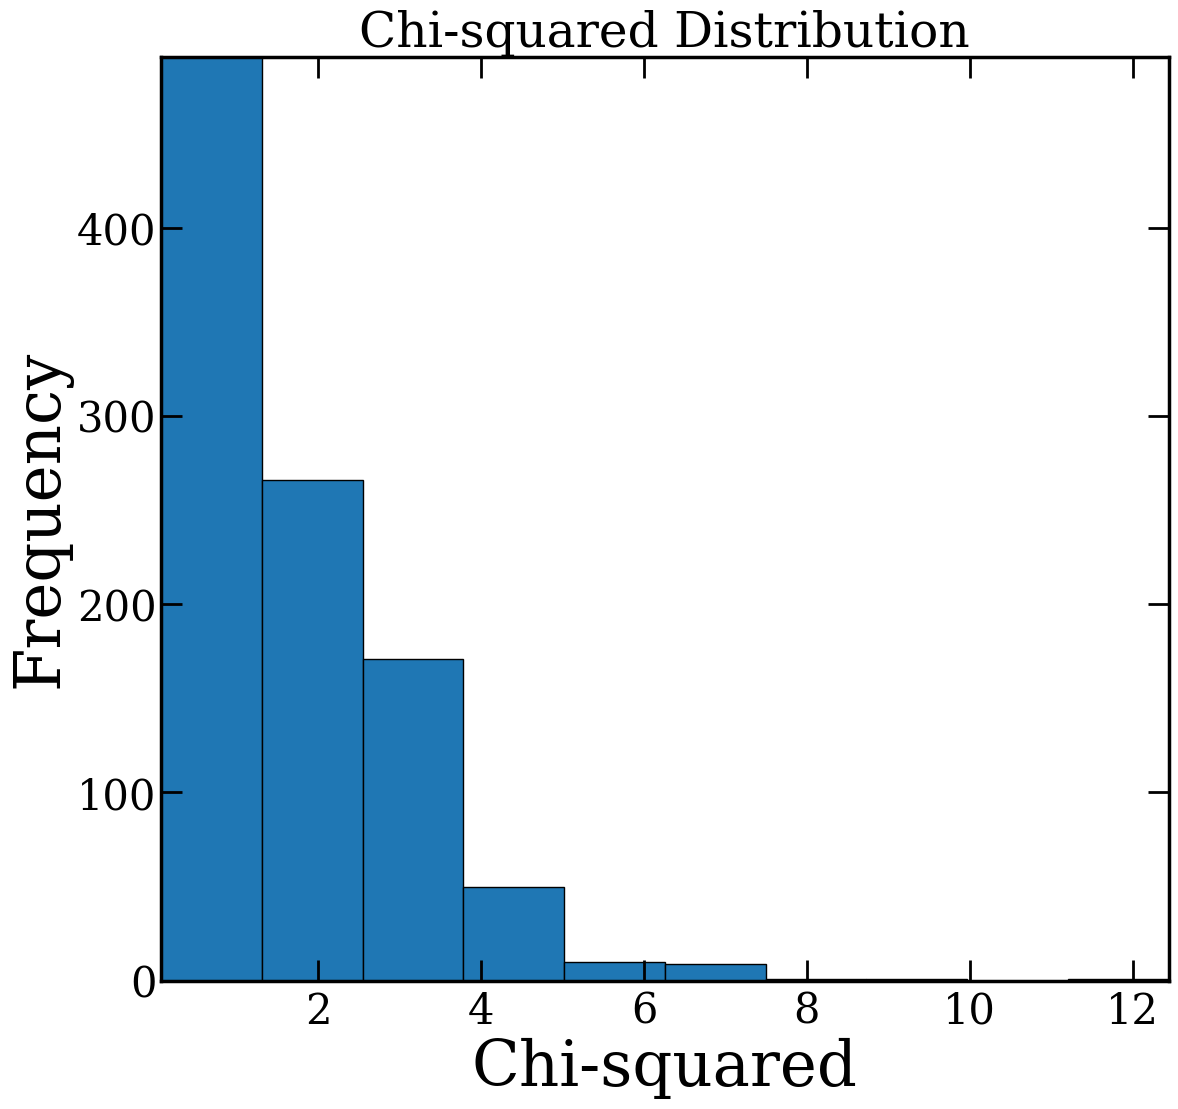

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming Rates_vector2 is your expected counts
# Replace with your actual data
#print(Rates_vector)

New = np.clip(Rates_vector, a_min=0, a_max=None)

N_expts = 1000
chi2 = np.zeros((N_expts))

for i in range(N_expts):
    # Simulate observed counts based on a Poisson distribution
    N_obs = np.random.poisson(New)
    # Calculate chi-squared
    chi2[i] = np.sum((New - N_obs)**2)

#erase this loop
chi3 = np.zeros((N_expts))
for i in range(N_expts):
    # Simulate observed counts based on a Poisson distribution
    N_obs = np.random.poisson(New)
    # Calculate chi-squared
    chi3[i] = np.sum((New - N_obs)**2)

chi2dog = chi3 + chi2 # lmoa idk why i did this 

# Plot the histogram of chi-squared values
plt.hist(chi2dog, bins=10, edgecolor='black')
plt.xlabel('Chi-squared')
plt.ylabel('Frequency')
plt.title('Chi-squared Distribution')
plt.show()


# We can use the curves shown above to figure out the cross section value we would need to observe a fixed number of events, say $N=3$. This can give us a sense of how the sensitivity of an experiment would be impacted by these same parameter choices.

What you do is work out the number of events for a reference cross section $\sigma_{\rm ref}$ and then figure how much bigger or smaller $\sigma$ has to be to give you a certain required number, say $N=3$.

(The latest LZ exclusion limit and the neutrino floor for xenon are included here for some added context, the data is included in the same directory)

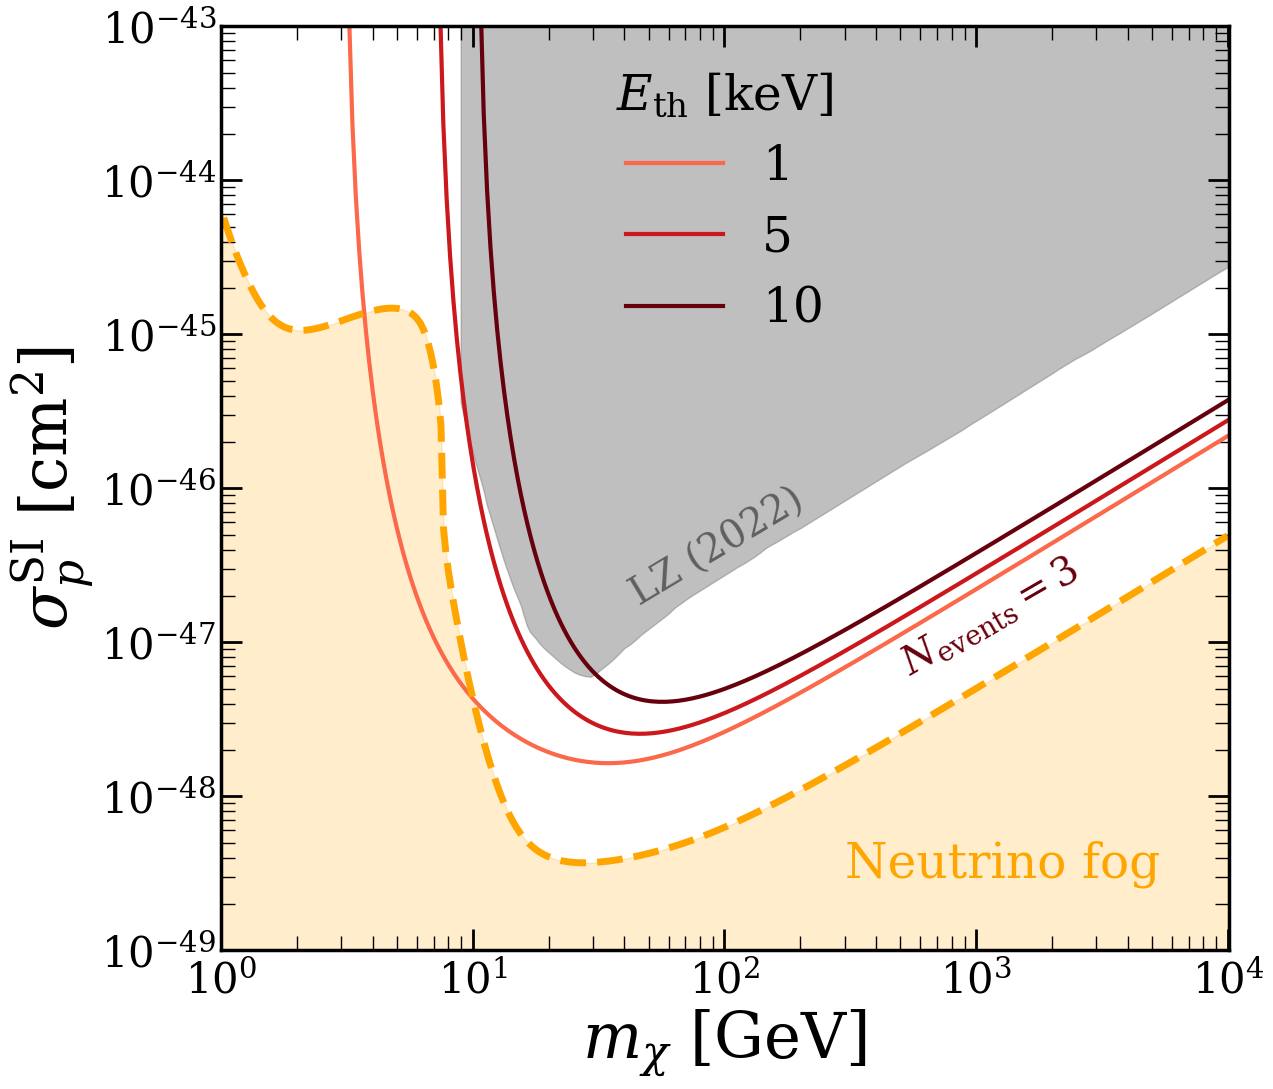

In [23]:
def sigma_fixedN(N_events,m_chi,dR_mass_function,sigma_ref,Exposure,E_th,E_max):
    # This function calculates the cross section required for a given detector to observe a fixed number of events N_events
    # dR_mass_function is a function of energy and the unkown dark matter mass
    # It will loop through a range of masses given by m_chi to produce a contour of values of sigma where the experiment observes a fixed number of events
    n = size(m_chi)
    sigma = zeros_like(m_chi)
    for i in range(0,n):
        dR = lambda E_r : dR_mass_function(E_r,m_chi[i])
        if dR(array([E_th]))[0]>0:
            N = NumberofEvents(dR,Exposure,E_th,E_max)
            sigma[i] = (N_events*sigma_ref)/N
        else:
            sigma[i] = inf
    return sigma

E_max = 100.0
N_events = 3

# Plot some N_events=3 lines for different threshold energies
for E_th,col in zip([1,5,10],cm.Reds([0.5,0.75,1.0])):
    g = lambda v_min : MeanInverseSpeed(v_min) #will need to modify this line with the addition of the term for 
    dR_mass = lambda E_r,m_chi : dRdE_SI(E_r,m_chi,sigma_ref,A,g)
    sigma = sigma_fixedN(N_events,m_chi_vals,dR_mass,sigma_ref,Exposure,E_th,E_max)
    plt.loglog(m_chi_vals,sigma,color=col,label=str(E_th))

plt.text(m_chi_vals[200],sigma[200]/3,r'$N_{\rm events} = 3$',color=col,rotation=30)
    
LZ = loadtxt('LZ_2022.txt')
plt.fill_between(LZ[:,0],LZ[:,1],y2=1,color='Gray',alpha=0.5)
plt.text(LZ[40,0],1.9*LZ[40,1],r'LZ (2022)',color='k',rotation=31,fontsize=28,alpha=0.5)

nufog = loadtxt('nufog-Xe.txt')
plt.fill_between(nufog[:,0],nufog[:,1],y2=1e-50,color='orange',alpha=0.2)
plt.plot(nufog[:,0],nufog[:,1],'--',lw=5,color='orange')
plt.text(0.3e3,3e-49,r'Neutrino fog',color='orange',rotation=0,fontsize=35)

plt.legend(title=r'$E_{\rm th}$ [keV]',loc='upper center')
plt.ylim(bottom=1e-49,top=1e-43)
plt.xlim(left=1)
plt.xlabel(r'$m_\chi$ [GeV]')
plt.ylabel(r'$\sigma^{\rm SI}_p$ [cm$^2$]');

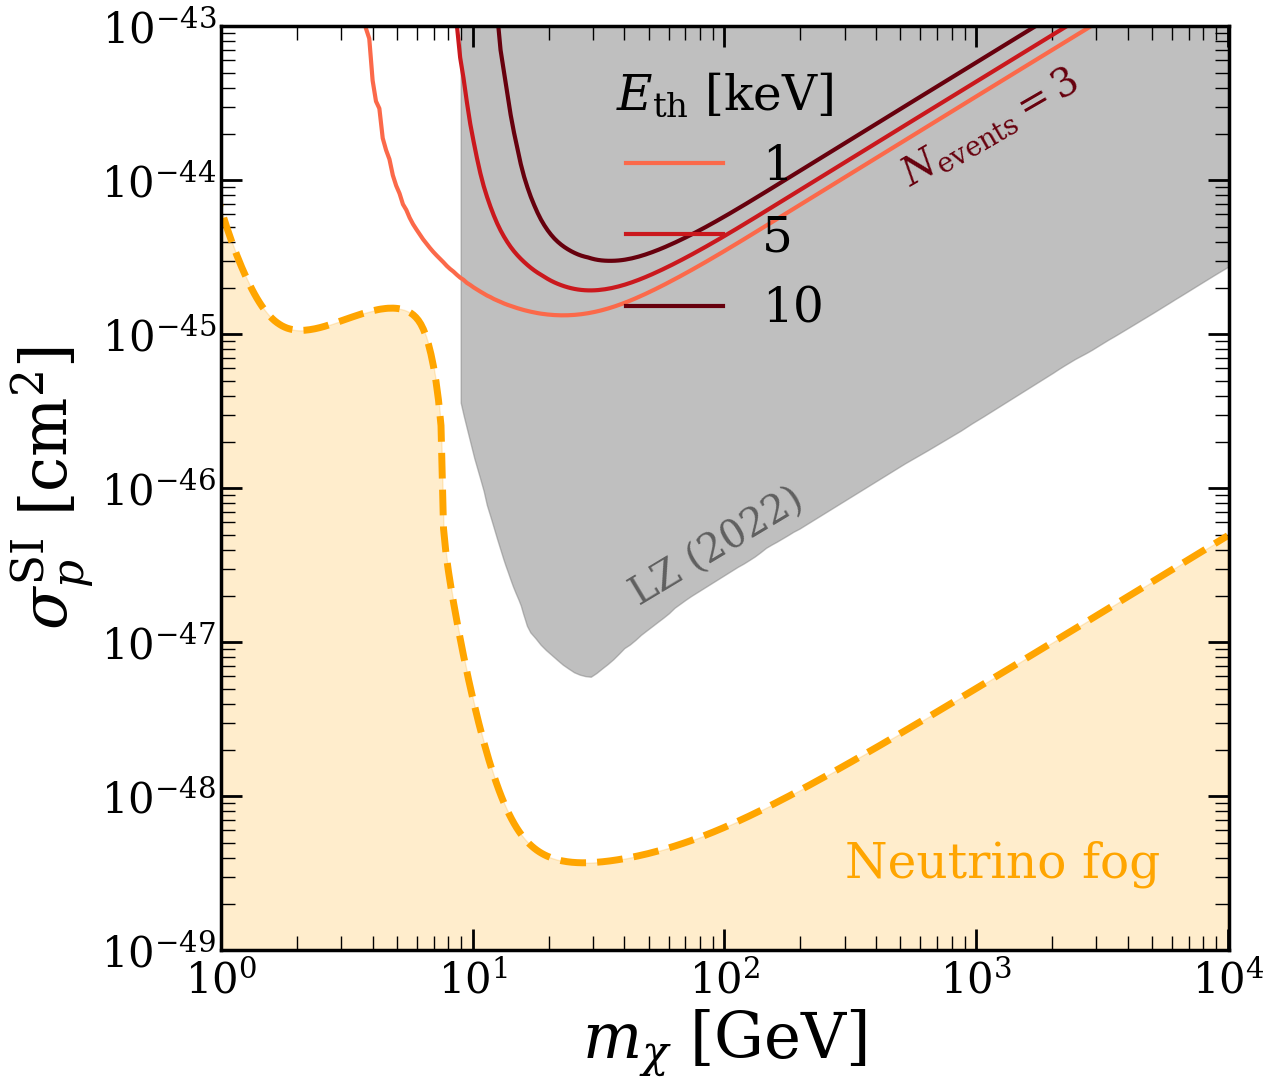

In [24]:
def sigma_fixedN(N_events,m_chi,dR_mass_function,sigma_ref,Exposure,E_th,E_max):
    # This function calculates the cross section required for a given detector to observe a fixed number of events N_events
    # dR_mass_function is a function of energy and the unkown dark matter mass
    # It will loop through a range of masses given by m_chi to produce a contour of values of sigma where the experiment observes a fixed number of events
    n = size(m_chi)
    sigma = zeros_like(m_chi)
    for i in range(0,n):
        dR = lambda E_r : dR_mass_function(E_r,m_chi[i])
        if dR(array([E_th]))[0]>0:
            N = NumberofEvents_2(dR,Exposure,E_th,E_max)
            sigma[i] = (N_events*sigma_ref)/N
        else:
            sigma[i] = inf
    return sigma

E_max = 100.0
N_events = 3

# Plot some N_events=3 lines for different threshold energies
for E_th,col in zip([1,5,10],cm.Reds([0.5,0.75,1.0])):
    g = lambda v_min : g_new3(v_min, Number=20, v_mean = 500, sigma_mean = 50)
    dR_mass = lambda E_r,m_chi : dRdE_SI_new_2(E_r,m_chi,sigma_ref,A,g)
    sigma = sigma_fixedN(N_events,m_chi_vals,dR_mass,sigma_ref,Exposure,E_th,E_max)
    plt.loglog(m_chi_vals,sigma,color=col,label=str(E_th))

plt.text(m_chi_vals[200],sigma[200]/3,r'$N_{\rm events} = 3$',color=col,rotation=30)
    
LZ = loadtxt('LZ_2022.txt')
plt.fill_between(LZ[:,0],LZ[:,1],y2=1,color='Gray',alpha=0.5)
plt.text(LZ[40,0],1.9*LZ[40,1],r'LZ (2022)',color='k',rotation=31,fontsize=28,alpha=0.5)

nufog = loadtxt('nufog-Xe.txt')
plt.fill_between(nufog[:,0],nufog[:,1],y2=1e-50,color='orange',alpha=0.2)
plt.plot(nufog[:,0],nufog[:,1],'--',lw=5,color='orange')
plt.text(0.3e3,3e-49,r'Neutrino fog',color='orange',rotation=0,fontsize=35)

plt.legend(title=r'$E_{\rm th}$ [keV]',loc='upper center')
plt.ylim(bottom=1e-49,top=1e-43)
plt.xlim(left=1)
plt.xlabel(r'$m_\chi$ [GeV]')
plt.ylabel(r'$\sigma^{\rm SI}_p$ [cm$^2$]');